# Conditional metrics: MAPIE vs covmetrics

This notebook compares the conditional metrics exposed by MAPIE with the original `covmetrics` implementation that MAPIE wraps.

The examples use two offline scikit-learn datasets and MAPIE's public split-conformal objects:

- `load_diabetes` with `SplitConformalRegressor` for regression prediction intervals;
- `load_wine` with `SplitConformalClassifier` for classification prediction sets.

MAPIE accepts user-facing conformal outputs: regression intervals or classification prediction sets. The `covmetrics` package expects a binary coverage vector instead. The comparison below checks both steps:

- generate conformal intervals and prediction sets with MAPIE objects;
- convert those MAPIE outputs into the same binary coverage vector expected by `covmetrics`;
- compare MAPIE's public metric results with direct calls to `covmetrics.CovGap`, `covmetrics.WSC`, and `covmetrics.ERT`;
- visualize coverage by group, local failures, and the final MAPIE-vs-`covmetrics` equality checks.

If every assertion passes, the MAPIE wrapper and the original `covmetrics` implementation return the same values on MAPIE conformal predictions.

In [1]:
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes, load_wine
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from covmetrics import CovGap, ERT, WSC
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook compares MAPIE against covmetrics. Install the "
        "conditional dependencies, for example with "
        "`pip install -e '.[conditional]'`, before running it."
    ) from exc

from mapie.classification import SplitConformalClassifier
from mapie.metrics.conditional import (
    coverage_gap,
    excess_risk_target_coverage,
    worst_slab_coverage,
)
from mapie.regression import SplitConformalRegressor

RANDOM_STATE = 42
CONFIDENCE_LEVEL = 0.9
WSC_KWARGS = {"delta": 0.2, "n_directions": 500, "random_state": RANDOM_STATE}
ERT_KWARGS = {
    "model_kwargs": {"max_iter": 100, "max_leaf_nodes": 31, "learning_rate": 0.1},
    "n_splits": 2,
    "random_state": RANDOM_STATE,
}

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed as a package"


pd.Series(
    {
        "MAPIE": installed_version("MAPIE"),
        "covmetrics": installed_version("covmetrics"),
        "scikit-learn": installed_version("scikit-learn"),
    },
    name="version",
)

MAPIE           1.4.2.dev29+g0db709851.d20260630
covmetrics                                 0.1.2
scikit-learn                               1.9.0
Name: version, dtype: object

## Shared helpers

MAPIE now performs the conformal prediction step. The first two helpers reproduce only the adaptation needed for the direct `covmetrics` comparison: they convert MAPIE intervals or prediction sets into binary coverage indicators.

In [3]:
def cover_from_intervals(y, y_intervals):
    y = np.asarray(y)
    y_intervals = np.asarray(y_intervals)
    if y_intervals.ndim == 3:
        y_intervals = y_intervals.squeeze(axis=2)
    return ((y >= y_intervals[:, 0]) & (y <= y_intervals[:, 1])).astype(int)


def cover_from_sets(y, y_sets):
    y = np.asarray(y, dtype=int)
    y_sets = np.asarray(y_sets, dtype=bool)
    if y_sets.ndim == 3:
        y_sets = y_sets.squeeze(axis=2)
    return y_sets[np.arange(y.shape[0]), y].astype(int)


def covmetrics_coverage_gap(groups, cover, confidence_level, weighted=False):
    alpha = 1 - confidence_level
    return float(CovGap().evaluate(groups, cover, alpha, weighted))


def covmetrics_worst_slab_coverage(
    x,
    cover,
    *,
    delta=0.2,
    n_directions=500,
    random_state=RANDOM_STATE,
):
    return float(WSC().evaluate(x, cover, delta=delta, M=n_directions, seed=random_state))


def covmetrics_excess_risk_target_coverage(
    x,
    cover,
    confidence_level,
    *,
    model_kwargs=None,
    n_splits=2,
    random_state=RANDOM_STATE,
):
    alpha = 1 - confidence_level
    model_kwargs = {} if model_kwargs is None else model_kwargs.copy()
    model_kwargs.setdefault("random_state", random_state)
    return float(
        ERT(model_cls=HistGradientBoostingClassifier, **model_kwargs).evaluate(
            x,
            cover,
            alpha,
            n_splits=n_splits,
            random_state=random_state,
        )
    )


def comparison_row(metric, case, mapie_value, covmetrics_value):
    return {
        "metric": metric,
        "case": case,
        "MAPIE": mapie_value,
        "covmetrics": covmetrics_value,
        "absolute_difference": abs(mapie_value - covmetrics_value),
    }


def group_coverage_frame(groups, cover, group_names=None):
    frame = pd.DataFrame({"group": groups, "covered": cover})
    summary = frame.groupby("group", sort=True).agg(
        coverage=("covered", "mean"),
        n_samples=("covered", "size"),
    )
    if group_names is not None:
        summary.index = [group_names[group] for group in summary.index]
    return summary


def split_train_calibration_test(
    X,
    y,
    *,
    stratify=None,
    test_size=0.25,
    calibration_size=0.25,
):
    X_fit, X_test, y_fit, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=stratify,
    )
    stratify_fit = y_fit if stratify is not None else None
    X_train, X_calib, y_train, y_calib = train_test_split(
        X_fit,
        y_fit,
        test_size=calibration_size,
        random_state=RANDOM_STATE,
        stratify=stratify_fit,
    )
    return X_train, X_calib, X_test, y_train, y_calib, y_test

## Regression: diabetes prediction intervals

A random forest base estimator is wrapped by `SplitConformalRegressor`. MAPIE fits the estimator, conformalizes on a held-out split, and returns prediction intervals. Conditional groups are quartiles of the test-set BMI feature.

In [4]:
diabetes = load_diabetes(as_frame=True)
X_diabetes = diabetes.data.to_numpy()
y_diabetes = diabetes.target.to_numpy()
bmi_feature_idx = diabetes.feature_names.index("bmi")

(
    X_train_reg,
    X_calib_reg,
    X_test_reg,
    y_train_reg,
    y_calib_reg,
    y_test_reg,
) = split_train_calibration_test(X_diabetes, y_diabetes)

base_regressor = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
)
mapie_regressor = SplitConformalRegressor(
    estimator=base_regressor,
    confidence_level=CONFIDENCE_LEVEL,
    prefit=False,
)
mapie_regressor.fit(X_train_reg, y_train_reg)
mapie_regressor.conformalize(X_calib_reg, y_calib_reg)
test_predictions, y_intervals = mapie_regressor.predict_interval(X_test_reg)

bmi_groups = np.asarray(pd.qcut(X_test_reg[:, bmi_feature_idx], q=4, labels=False, duplicates="drop"))
bmi_group_names = {group: f"BMI Q{group + 1}" for group in np.unique(bmi_groups)}
cover_regression = cover_from_intervals(y_test_reg, y_intervals)

regression_group_coverage = group_coverage_frame(
    bmi_groups,
    cover_regression,
    group_names=bmi_group_names,
)
regression_group_coverage

,coverage,n_samples
BMI Q1,1.000000,28
BMI Q2,0.966667,30
BMI Q3,0.960000,25
BMI Q4,0.928571,28


In [5]:
regression_rows = []

for weighted in [False, True]:
    regression_rows.append(
        comparison_row(
            "CovGap" if not weighted else "WCovGap",
            "diabetes regression intervals",
            coverage_gap(
                y_test_reg,
                bmi_groups,
                CONFIDENCE_LEVEL,
                y_intervals=y_intervals,
                weighted=weighted,
            ),
            covmetrics_coverage_gap(
                bmi_groups,
                cover_regression,
                CONFIDENCE_LEVEL,
                weighted=weighted,
            ),
        )
    )

regression_rows.append(
    comparison_row(
        "WSC",
        "diabetes regression intervals",
        worst_slab_coverage(
            X_test_reg,
            y_test_reg,
            y_intervals=y_intervals,
            **WSC_KWARGS,
        ),
        covmetrics_worst_slab_coverage(
            X_test_reg,
            cover_regression,
            **WSC_KWARGS,
        ),
    )
)

regression_rows.append(
    comparison_row(
        "ERT",
        "diabetes regression intervals",
        excess_risk_target_coverage(
            X_test_reg,
            y_test_reg,
            CONFIDENCE_LEVEL,
            y_intervals=y_intervals,
            **ERT_KWARGS,
        ),
        covmetrics_excess_risk_target_coverage(
            X_test_reg,
            cover_regression,
            CONFIDENCE_LEVEL,
            **ERT_KWARGS,
        ),
    )
)

regression_comparison = pd.DataFrame(regression_rows)
np.testing.assert_allclose(regression_comparison["MAPIE"], regression_comparison["covmetrics"])
regression_comparison

,metric,case,MAPIE,covmetrics,absolute_difference
0,CovGap,diabetes regression intervals,0.063810,0.063810,0.0
1,WCovGap,diabetes regression intervals,0.063964,0.063964,0.0
2,WSC,diabetes regression intervals,0.826087,0.826087,0.0
3,ERT,diabetes regression intervals,0.047597,0.047597,0.0


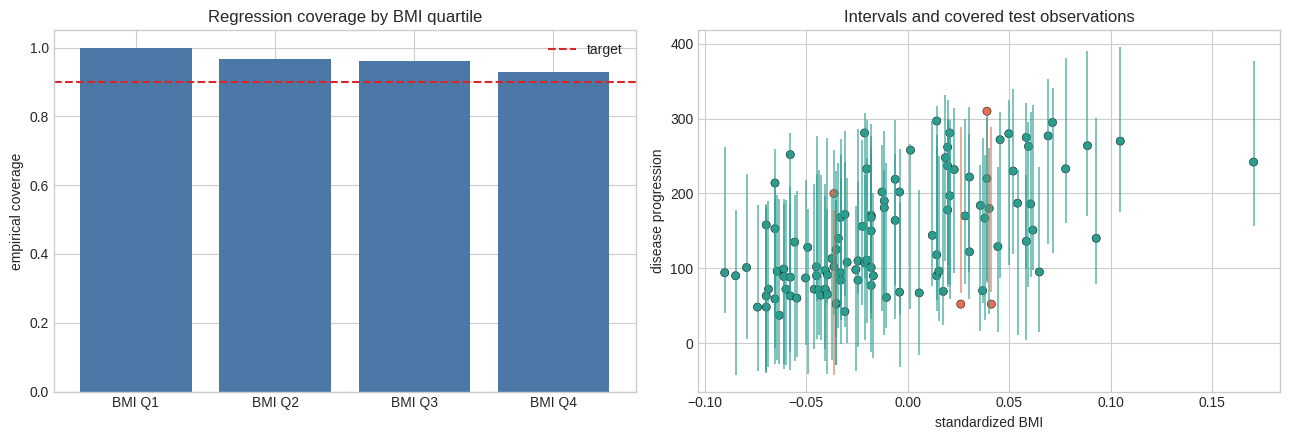

In [6]:
intervals_2d = y_intervals.squeeze(axis=2)
order = np.argsort(X_test_reg[:, bmi_feature_idx])
colors = np.where(cover_regression[order] == 1, "#2a9d8f", "#e76f51")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    regression_group_coverage.index,
    regression_group_coverage["coverage"],
    color="#4c78a8",
)
axes[0].axhline(CONFIDENCE_LEVEL, color="#d62728", linestyle="--", label="target")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("empirical coverage")
axes[0].set_title("Regression coverage by BMI quartile")
axes[0].legend()

axes[1].vlines(
    X_test_reg[:, bmi_feature_idx][order],
    intervals_2d[order, 0],
    intervals_2d[order, 1],
    color=colors,
    alpha=0.65,
    linewidth=1.3,
)
axes[1].scatter(
    X_test_reg[:, bmi_feature_idx][order],
    y_test_reg[order],
    c=colors,
    edgecolor="black",
    linewidth=0.35,
    s=35,
)
axes[1].set_xlabel("standardized BMI")
axes[1].set_ylabel("disease progression")
axes[1].set_title("Intervals and covered test observations")

fig.tight_layout()

## Classification: wine prediction sets

A standardized multinomial logistic regression base estimator is wrapped by `SplitConformalClassifier`. MAPIE fits the estimator, conformalizes on a held-out split, and returns prediction sets. Conditional groups are the true wine classes, which corresponds to a class-conditional coverage diagnostic.

In [7]:
wine = load_wine(as_frame=True)
X_wine = wine.data.to_numpy()
y_wine = wine.target.to_numpy()

(
    X_train_clf,
    X_calib_clf,
    X_test_clf,
    y_train_clf,
    y_calib_clf,
    y_test_clf,
) = split_train_calibration_test(X_wine, y_wine, stratify=y_wine)

base_classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)
mapie_classifier = SplitConformalClassifier(
    estimator=base_classifier,
    confidence_level=CONFIDENCE_LEVEL,
    conformity_score="lac",
    prefit=False,
    random_state=RANDOM_STATE,
)
mapie_classifier.fit(X_train_clf, y_train_clf)
mapie_classifier.conformalize(X_calib_clf, y_calib_clf)
predicted_labels, y_sets = mapie_classifier.predict_set(X_test_clf)

class_groups = y_test_clf.copy()
class_group_names = {class_id: wine.target_names[class_id] for class_id in np.unique(class_groups)}
cover_classification = cover_from_sets(y_test_clf, y_sets)
set_sizes = y_sets.squeeze(axis=2).sum(axis=1)

classification_group_coverage = group_coverage_frame(
    class_groups,
    cover_classification,
    group_names=class_group_names,
)
classification_group_coverage

,coverage,n_samples
class_0,0.933333,15
class_1,0.888889,18
class_2,0.750000,12


In [8]:
classification_rows = []

for weighted in [False, True]:
    classification_rows.append(
        comparison_row(
            "CovGap" if not weighted else "WCovGap",
            "wine classification sets",
            coverage_gap(
                y_test_clf,
                class_groups,
                CONFIDENCE_LEVEL,
                y_sets=y_sets,
                weighted=weighted,
            ),
            covmetrics_coverage_gap(
                class_groups,
                cover_classification,
                CONFIDENCE_LEVEL,
                weighted=weighted,
            ),
        )
    )

classification_rows.append(
    comparison_row(
        "WSC",
        "wine classification sets",
        worst_slab_coverage(
            X_test_clf,
            y_test_clf,
            y_sets=y_sets,
            **WSC_KWARGS,
        ),
        covmetrics_worst_slab_coverage(
            X_test_clf,
            cover_classification,
            **WSC_KWARGS,
        ),
    )
)

classification_rows.append(
    comparison_row(
        "ERT",
        "wine classification sets",
        excess_risk_target_coverage(
            X_test_clf,
            y_test_clf,
            CONFIDENCE_LEVEL,
            y_sets=y_sets,
            **ERT_KWARGS,
        ),
        covmetrics_excess_risk_target_coverage(
            X_test_clf,
            cover_classification,
            CONFIDENCE_LEVEL,
            **ERT_KWARGS,
        ),
    )
)

classification_comparison = pd.DataFrame(classification_rows)
np.testing.assert_allclose(classification_comparison["MAPIE"], classification_comparison["covmetrics"])
classification_comparison

,metric,case,MAPIE,covmetrics,absolute_difference
0,CovGap,wine classification sets,0.064815,0.064815,0.0
1,WCovGap,wine classification sets,0.055556,0.055556,0.0
2,WSC,wine classification sets,0.555556,0.555556,0.0
3,ERT,wine classification sets,-0.047431,-0.047431,0.0


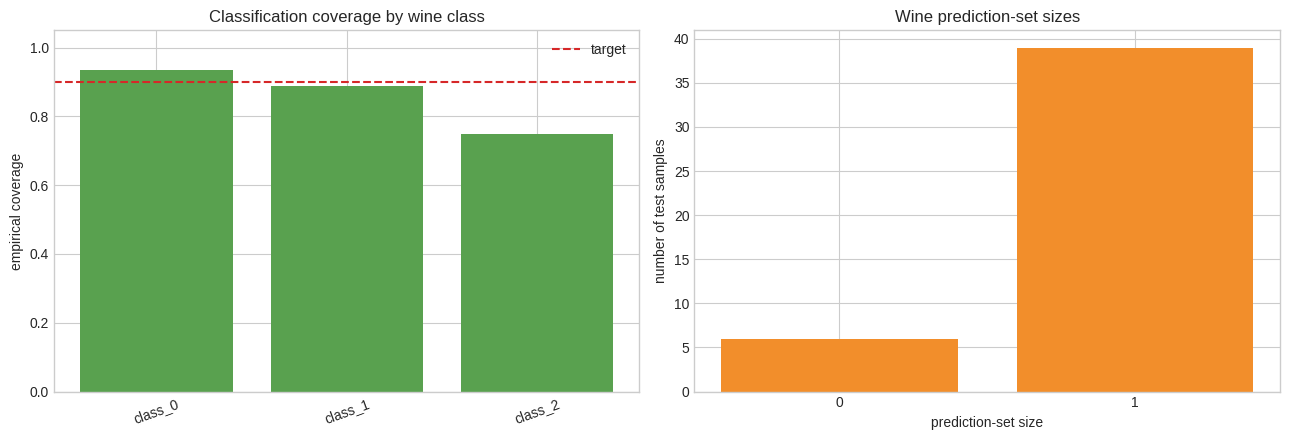

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    classification_group_coverage.index,
    classification_group_coverage["coverage"],
    color="#59a14f",
)
axes[0].axhline(CONFIDENCE_LEVEL, color="#d62728", linestyle="--", label="target")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("empirical coverage")
axes[0].set_title("Classification coverage by wine class")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

set_size_counts = pd.Series(set_sizes).value_counts().sort_index()
axes[1].bar(set_size_counts.index.astype(str), set_size_counts.values, color="#f28e2b")
axes[1].set_xlabel("prediction-set size")
axes[1].set_ylabel("number of test samples")
axes[1].set_title("Wine prediction-set sizes")

fig.tight_layout()

## Combined MAPIE vs covmetrics comparison

The bars below should coincide for every row. The `absolute_difference` column is also asserted to be numerically zero up to floating-point tolerance.

In [10]:
comparison = pd.concat(
    [regression_comparison, classification_comparison],
    ignore_index=True,
)
np.testing.assert_allclose(comparison["MAPIE"], comparison["covmetrics"])
comparison

,metric,case,MAPIE,covmetrics,absolute_difference
0,CovGap,diabetes regression intervals,0.063810,0.063810,0.0
1,WCovGap,diabetes regression intervals,0.063964,0.063964,0.0
2,WSC,diabetes regression intervals,0.826087,0.826087,0.0
3,ERT,diabetes regression intervals,0.047597,0.047597,0.0
4,CovGap,wine classification sets,0.064815,0.064815,0.0
5,WCovGap,wine classification sets,0.055556,0.055556,0.0
6,WSC,wine classification sets,0.555556,0.555556,0.0
7,ERT,wine classification sets,-0.047431,-0.047431,0.0


All MAPIE conditional metric values match direct covmetrics calls.


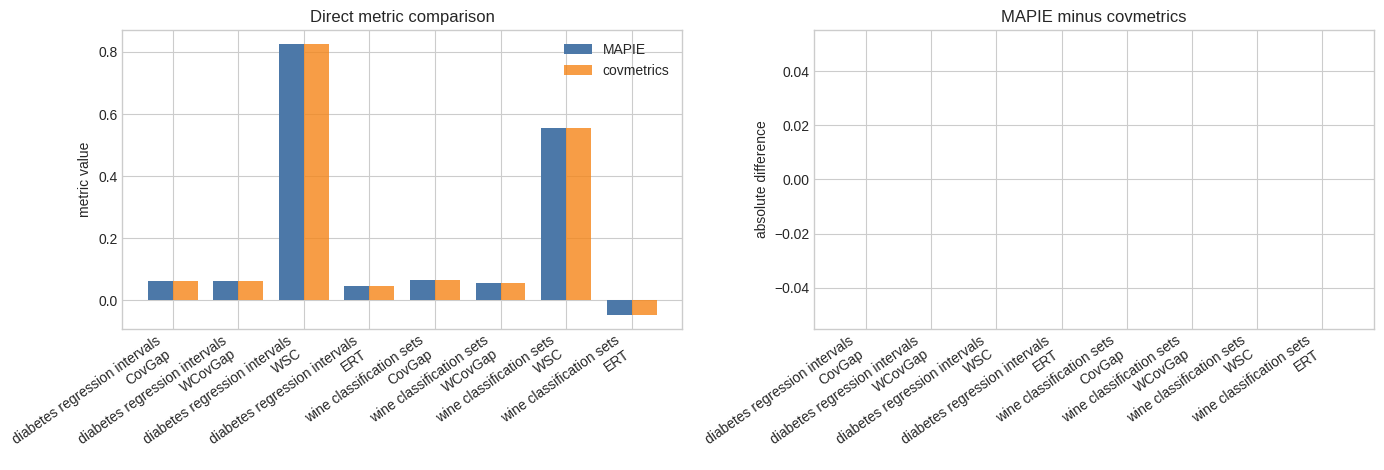

In [11]:
plot_frame = comparison.copy()
plot_frame["label"] = plot_frame["case"] + "\n" + plot_frame["metric"]

x_positions = np.arange(plot_frame.shape[0])
bar_width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].bar(
    x_positions - bar_width / 2,
    plot_frame["MAPIE"],
    width=bar_width,
    label="MAPIE",
    color="#4c78a8",
)
axes[0].bar(
    x_positions + bar_width / 2,
    plot_frame["covmetrics"],
    width=bar_width,
    label="covmetrics",
    color="#f58518",
    alpha=0.8,
)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(plot_frame["label"], rotation=35, ha="right")
axes[0].set_ylabel("metric value")
axes[0].set_title("Direct metric comparison")
axes[0].legend()

axes[1].bar(plot_frame["label"], plot_frame["absolute_difference"], color="#b279a2")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(plot_frame["label"], rotation=35, ha="right")
axes[1].set_ylabel("absolute difference")
axes[1].set_title("MAPIE minus covmetrics")

fig.tight_layout()

print("All MAPIE conditional metric values match direct covmetrics calls.")